# Approximate Hybrid Quantum State Preparation for a Single-Gaussian Signal

## Imports

In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from hybridqsp.transforms import dft, idft
from hybridqsp.transforms import haar_packet_transform, inverse_haar_packet_transform
from hybridqsp.quantum import build_inverse_qphwt_circuit
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analysis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

## Signal Generation

A single-Gaussian signal is generated as a representative smooth localized waveform for transform-domain sparsity analysis.

In [3]:
n = 10    # Number of qubit
N = 2**n  # Number of quantum basis

x  = np.linspace(-5, 5, N)
mu, sigma, amp = 0.0, 0.8, 1.0
g = amp * np.exp(-(x - mu)**2 / (2.0 * sigma**2))

target_f =  g / np.linalg.norm(g)

k= 10 | TD=2.419165e-02 | Fidelity=0.9994147642


C:\Users\emadb\.conda\envs\quantum_env_backup\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\emadb\.conda\envs\quantum_env_backup\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


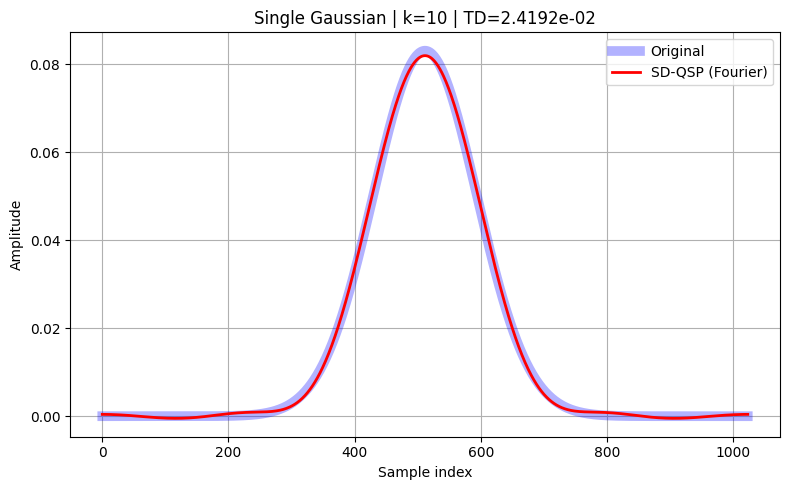

In [9]:
# ============================================================
# DFT compression of Single Gaussian
# ============================================================
# --------------------------------------------------------
# Forward transform
# --------------------------------------------------------
X = dft(g)

# --------------------------------------------------------
# Top-k threshold
# --------------------------------------------------------
k=10
Xk = top_k_threshold(
        X,
        k
    )

# Remove negligible imaginary part
Xt = np.real_if_close(Xk)

x_norm = Xt/np.linalg.norm(Xt)
# --------------------------------------------------------
# Reconstruction
# --------------------------------------------------------
rec = idft(x_norm)


# --------------------------------------------------------
# Metrics
# --------------------------------------------------------

TD = trace_distance(target_f, rec)
F = state_fidelity(target_f, rec)

print(
      f"k={k:3d} | "
      f"TD={TD:.6e} | "
      f"Fidelity={F:.10f}"
    )

# --------------------------------------------------------
# Plot
# --------------------------------------------------------

plt.figure(figsize=(8,5))
plt.plot(
        target_f,
        color="blue",
        lw=7,
        alpha=0.30,
        label="Original"
    )

plt.plot(
      rec,
        color="red",
        lw=2,
        label="SD-QSP (Fourier)"
    )

plt.title(f"Single Gaussian | "f"k={k} | TD={TD:.4e}"   )

plt.xlabel("Sample index")
plt.ylabel("Amplitude")

plt.grid(True)
plt.legend()

plt.savefig("../figures/SG_dft.pdf")

plt.tight_layout()
plt.show()

In [5]:
from qibo import Circuit, gates
from qibo.models import QFT
from qibo.models.encodings import sparse_encoder
from qibo.ui import plot_circuit

In [6]:
vec = x_norm

nz = np.flatnonzero(vec)             # Nonzero indices

y = [(format(i, f"0{n}b"), vec[i]) for i in nz]

# ------------------------------------------------
# Sparse encoder circuit
# ------------------------------------------------
circuit = sparse_encoder(y, method="farias")

# ------------------------------------------------
# inverse QFT
# ------------------------------------------------
iqft = QFT(nqubits=n).invert()

circuit.add(iqft.on_qubits(*range(n)))

print(circuit.decompose().decompose().summary())

[Qibo 0.3.5|INFO|2026-07-11 02:10:06]: Using numpy backend on /CPU:0


Circuit depth = 147
Total number of gates = 342
Number of qubits = 10
Most common gates:
rz: 152
cx: 143
x: 16
h: 14
ry: 13
rx: 4
None
